In [1]:
import os
if os.getenv("COLAB_RELEASE_TAG"):
    import subprocess
    subprocess.run('wget https://raw.githubusercontent.com/luigibonati/mlcolvar/main/colab_setup.sh', shell=True)
    cmd = subprocess.run('bash colab_setup.sh TUTORIAL', shell=True, stdout=subprocess.PIPE)
    print(cmd.stdout.decode('utf-8'))

# IMPORT PACKAGES
import torch
import lightning
import numpy as np
import matplotlib.pyplot as plt

# IMPORT HELPER FUNCTIONS
from mlcolvar.utils.plot import muller_brown_potential, plot_isolines_2D, plot_metrics

# Set seed for reproducibility
torch.manual_seed(42)

/home/sompriya/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import pandas as pd
from mlcolvar.utils.io import load_dataframe
from mlcolvar.utils.timelagged import create_timelagged_dataset
from mlcolvar.data import DictModule
import numpy as np


df = load_dataframe('COLVAR_multiT_new',start=10000,stop=100000)
df

/home/sompriya/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/sompriya/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


,time,lassoCV_node0,lassoCV_node1,ene,ecv.ene,opes.bias,cos1,cos2,cos3,cos4,...,cos16,cos17,cos18,cos19,cos20,cos21,cos22,cos23,cos24,walker
0,10000.000475,-0.754425,-0.737791,-87005.539062,-87005.539062,3.127852,0.568013,0.209361,-0.857766,0.692915,...,0.363070,-0.978425,0.916834,-0.870166,-0.809504,-0.975503,0.356849,0.206942,-0.788538,0
1,10001.000475,-0.743783,-0.754114,-86835.515625,-86835.515625,-0.866347,0.272502,0.211039,-0.830069,0.615779,...,0.179181,-0.999701,0.978472,-0.971320,-0.713936,-0.998499,0.358464,0.028654,-0.872690,0
2,10002.000475,-0.706291,-0.763173,-86562.679688,-86562.679688,-16.973207,0.436020,0.120670,-0.763461,0.614717,...,0.204992,-0.999999,0.992439,-0.974507,-0.410217,-0.999971,0.569429,-0.010744,-0.699784,0
3,10003.000475,-0.714328,-0.714094,-86044.476562,-86044.476562,-80.078491,0.491147,0.303814,-0.813598,0.666654,...,0.264859,-0.852598,0.723803,-0.856153,-0.812345,-0.967379,0.607472,0.088446,-0.484662,0
4,10004.000475,-0.662268,-0.724482,-86425.703125,-86425.703125,-30.009011,0.225313,0.201811,-0.472162,0.519030,...,0.090796,-0.923353,0.889150,-0.961975,-0.673096,-0.988710,0.626208,0.307634,-0.890309,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,99995.004750,-0.755509,-0.645269,-86207.203125,-86207.203125,-54.999871,0.666203,0.175475,-0.926650,0.786558,...,0.119885,-0.997980,0.351576,-0.913826,0.343280,-0.984602,0.627559,-0.829209,-0.762380,0
89996,99996.004750,-0.655586,-0.577226,-86449.726562,-86449.726562,-26.146025,0.636100,0.029789,-0.841942,0.796199,...,-0.031397,-0.998888,0.648640,-0.572436,-0.058836,-0.989101,0.598688,-0.623832,-0.515970,0
89997,99997.004750,-0.617102,-0.734250,-86459.617188,-86459.617188,-25.156056,0.513463,0.006053,-0.591128,0.424627,...,0.113886,-0.995147,0.529620,-0.972280,0.453368,-0.980320,0.279708,-0.757373,-0.656929,0
89998,99998.004750,-0.647146,-0.704681,-86808.125000,-86808.125000,-1.365861,0.571550,0.097403,-0.889745,0.644592,...,0.079427,-0.992722,0.840477,-0.840025,0.141627,-0.999995,0.378824,-0.598154,-0.544247,0


In [3]:
# Select input features
X = df.filter(regex='cos').values
n_input = X.shape[1]

print(X.shape)
print(X)

(90000, 24)
[[ 0.568013  0.209361 -0.857766 ...  0.356849  0.206942 -0.788538]
 [ 0.272502  0.211039 -0.830069 ...  0.358464  0.028654 -0.87269 ]
 [ 0.43602   0.12067  -0.763461 ...  0.569429 -0.010744 -0.699784]
 ...
 [ 0.513463  0.006053 -0.591128 ...  0.279708 -0.757373 -0.656929]
 [ 0.57155   0.097403 -0.889745 ...  0.378824 -0.598154 -0.544247]
 [ 0.443204  0.165345 -0.753855 ...  0.337078 -0.694777 -0.381108]]


In [4]:
#------------- PARAMETERS -------------
multicanonical    = True
temp              = 275.
temp0             = 275.
#--------------------------------------

# Calculate inverse temperature
kb=0.008314
beta=1./(kb*temp)
beta0=1./(kb*temp0)

# Extract cvs from df

t = df['time'].values # save time
ene = df['ene'].values.astype(np.float64) # store energy as long double
bias = df.filter(regex='.bias').values.sum(axis=1) # Load *.bias columns and sum them

# Compute log-weights for time reweighting
logweights = beta*bias

if multicanonical:
    ene -= np.mean(ene) #first shift energy by its mean value
    logweights += (beta0-beta)*ene

In [5]:
#------------- PARAMETERS -------------
lag_time = 100.
#--------------------------------------

# create dataset
dataset = create_timelagged_dataset(X,t,lag_time=lag_time,logweights=logweights,progress_bar=True)
#dataset = create_timelagged_dataset(X,t,lag_time=lag_time,progress_bar=True)

# create datamodule (split train valid)
datamodule = DictModule(dataset,lengths=[0.8,0.2],random_split=False,shuffle=False)

datamodule

100%|████████████████████████████████████| 89778/89778 [04:20<00:00, 344.98it/s]
/home/sompriya/.local/lib/python3.10/site-packages/mlcolvar/utils/timelagged.py:186: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:275.)
  x_t = torch.stack(x_t) if type(x) == torch.Tensor else torch.Tensor(x_t)
/home/sompriya/.local/lib/python3.10/site-packages/mlcolvar/data/datamodule.py:134: UserWarning: A torch.generator was provided but it is not used with random_split=False
  warnings.warn(


DictModule(dataset -> DictDataset( "data": [179165, 24], "data_lag": [179165, 24], "weights": [179165], "weights_lag": [179165] ),
		     train_loader -> DictLoader(length=0.8, batch_size=0, shuffle=False),
		     valid_loader -> DictLoader(length=0.2, batch_size=0, shuffle=False))

In [6]:
from mlcolvar.cvs import DeepTICA

n_components = 2
nn_layers = [n_input, 16, 12, n_components]
options= {'nn': {'activation': 'shifted_softplus'}}

model = DeepTICA(nn_layers, options=options)
model

DeepTICA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=24, out_features=24, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=24, out_features=16, bias=True)
      (1): Shifted_Softplus(beta=1, threshold=20)
      (2): Linear(in_features=16, out_features=12, bias=True)
      (3): Shifted_Softplus(beta=1, threshold=20)
      (4): Linear(in_features=12, out_features=2, bias=True)
    )
  )
  (tica): TICA(in_features=2, out_features=2)
)

In [7]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from mlcolvar.utils.trainer import MetricsCallback

# define callbacks
metrics = MetricsCallback()
early_stopping = EarlyStopping(monitor="valid_loss", min_delta=1e-3, patience=100)

# define trainer
trainer = lightning.Trainer(callbacks=[metrics, early_stopping],
                     max_epochs=None, logger=None, enable_checkpointing=False)

# fit
torch.set_float32_matmul_precision('medium')
trainer.fit( model, datamodule )

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/sompriya/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/home/sompriya/.local/lib/python3.10/site-packages/lightning/pytorch/

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/sompriya/.local/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

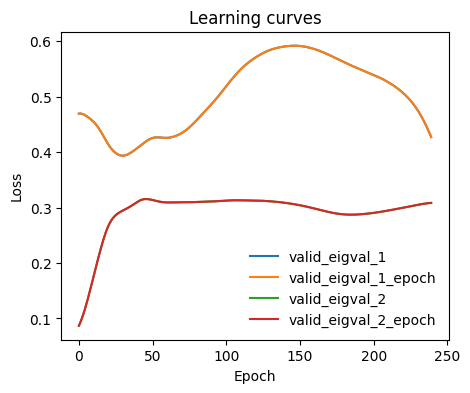

In [8]:
from mlcolvar.utils.plot import plot_metrics

ax = plot_metrics(metrics.metrics,
                  keys=[x for x in  metrics.metrics.keys() if 'valid_eigval' in x],#['train_loss_epoch','valid_loss'],
                  #linestyles=['-.','-'], colors=['fessa1','fessa5'],
                  yscale='linear')

In [9]:
from mlcolvar.core.transform import Normalization
from mlcolvar.core.transform.utils import Statistics

#X = dataset[:]['data']
with torch.no_grad():
    model.postprocessing = None # reset
    s = model(torch.Tensor(X))

norm =  Normalization(n_components, mode='min_max', stats = Statistics(s) )
model.postprocessing = norm

Text(0, 0.5, 'Deep-TICA 2')

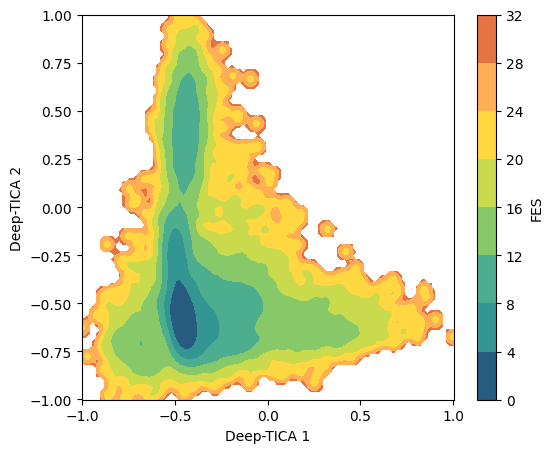

In [20]:
from mlcolvar.utils.fes import compute_fes

fig,ax = plt.subplots(1,1,figsize=(6,5),dpi=100)

# compute cvs
with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()

w = np.exp(logweights)
fes,grid,bounds,error = compute_fes(s,
                                    blocks=1, #weights=w,
                                    bandwidth=0.01, scale_by='range',
                                    plot=True, plot_max_fes=30, ax = ax, eps=1e-8)

ax.set_xlabel('Deep-TICA 1') 
ax.set_ylabel('Deep-TICA 2')
#plt.savefig('Deep_TICA_multiT_aaaa_mod.png',dpi=300,bbox_inches='tight')

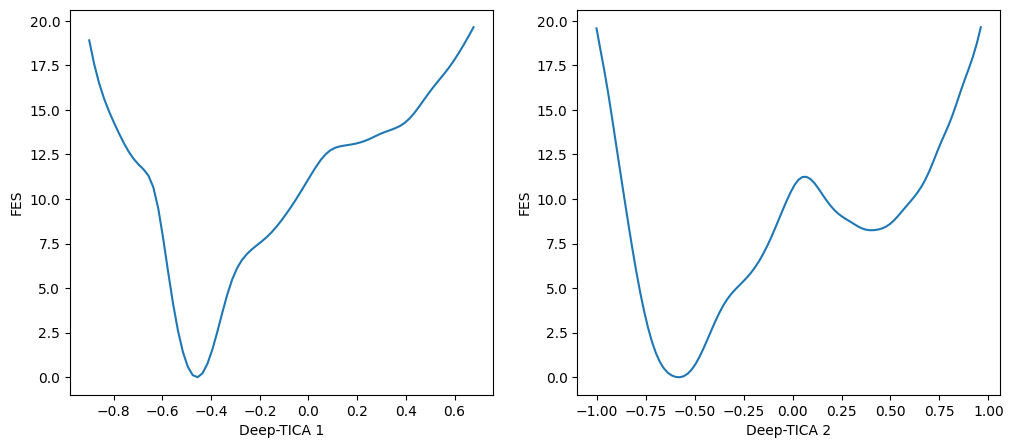

In [11]:
from mlcolvar.utils.fes import compute_fes

fig,axs = plt.subplots(1,n_components,figsize=(6*n_components,5),dpi=100)

for i in range(n_components):
    #w = np.exp(logweights)

    # restrict the second CV to the points in which the first is < 0
    fes,grid,bounds,error = compute_fes(s[:,i] if i == 0 else s[s[:,0] < 0, i ],
                                        #weights=w if i == 0 else w[s[:,0] < 0 ],
                                        blocks=1,
                                        bandwidth=0.02,scale_by='range',
                                        plot=True, plot_max_fes=20, ax = axs[i])
    axs[i].set_xlabel('Deep-TICA '+str(i+1))

In [12]:
## Save the model
x = torch.rand(n_input, dtype=torch.float32, requires_grad=True).unsqueeze(0)
traced_cv = torch.jit.trace ( model, example_inputs=x)
filename='rna_tetra_mutiT_deeptica_cccc_mod.pt'
traced_cv.save(filename)

/home/sompriya/.local/lib/python3.10/site-packages/mlcolvar/core/nn/utils.py:13: TracerWarning: Converting a tensor to a Python number might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  sp0 = F.softplus(torch.zeros(1), self.beta, self.threshold).item()
/home/sompriya/.local/lib/python3.10/site-packages/torch/jit/_trace.py:165: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  if a.grad is n

In [13]:
#Lasso Regression delete low weitage NN
from sklearn import linear_model
from sklearn.linear_model import LassoCV

with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()
tic0 = s[:,0]#select DeepTICA 1

reg0 = LassoCV(cv=5, random_state=0, max_iter=10000).fit(X, tic0)
print(reg0.coef_)
print(reg0.intercept_)
np.savetxt('tica1_coeff.txt',reg0.coef_,fmt='%0.3f')

[-0.00722799 -0.16395428  0.09349874 -0.01516102  0.13651051 -0.04932509
 -0.15386822  0.10320717 -0.13958875  0.09219815 -0.00615007 -0.03402295
 -0.08978214  0.0542382   0.01190869 -0.17127908  0.07037574  0.01577551
 -0.07406034  0.00361835  0.04236735 -0.00071579  0.02481401  0.01748709]
-0.21194086100700452


In [14]:
#Lasso Regression delete low weitage NN
from sklearn import linear_model
from sklearn.linear_model import LassoCV

with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()
tic1 = s[:,1]#select DeepTICA 2

reg1 = LassoCV(cv=5, random_state=0, max_iter=10000).fit(X, tic1)
print(reg1.coef_)
print(reg1.intercept_)
np.savetxt('tica2_coeff.txt',reg1.coef_,fmt='%0.3f')

[ 0.02543877 -0.02309814  0.02332544 -0.02743091  0.03928556 -0.00590752
  0.0405621   0.06160122  0.07579429 -0.15153645 -0.09737968  0.01101791
  0.09068847 -0.02130285  0.          0.17235799  0.29326236 -0.00057314
  0.09633918 -0.28375489  0.07717831  0.01803386 -0.20880679 -0.06193916]
-0.27970484683002317


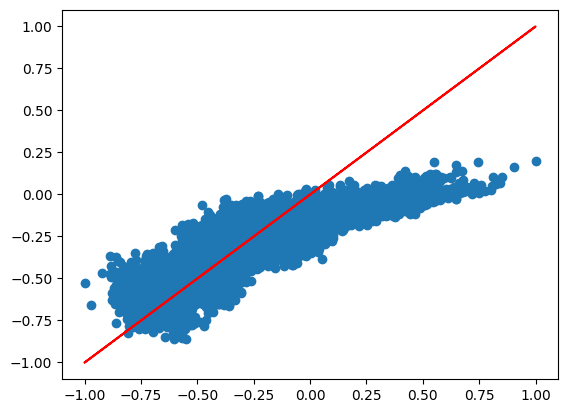

In [15]:
X_np = torch.Tensor(X).numpy()
ypred = reg0.predict(X)

plt.scatter(tic0,ypred)
plt.plot(tic0,tic0,c='r') # X axis=DeepTICA 1 CV, Y axis= lassoCV, 

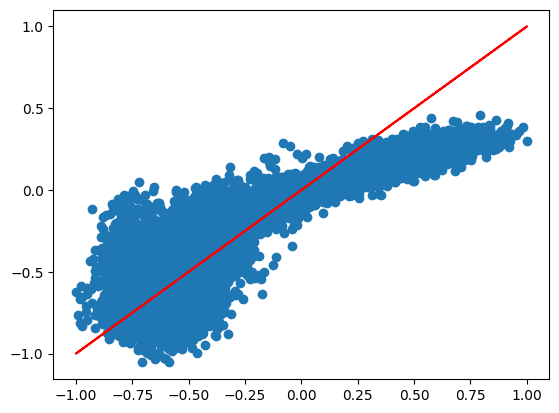

In [16]:
X_np = torch.Tensor(X).numpy()
ypred = reg1.predict(X)

plt.scatter(tic1,ypred)
plt.plot(tic1,tic1,c='r') # X axis=DeepTICA 2 CV, Y axis= lassoCV, 

In [17]:
s='lasso_node0: COMBINE ARG='
for i in range(len(reg0.coef_)):
    if reg0.coef_[i] != 0:
        s+= 'cos%d'%(i+1)
        if i < len(reg0.coef_) - 1:
            s+= ','
s+= ' COEFFICIENTS='

for i in range(len(reg0.coef_)):
    if reg0.coef_[i] != 0:
        s+= '%0.4f'%reg0.coef_[i]
        if i < len(reg0.coef_) - 1:
            s+= ','
s+= ' PERIODIC=NO'
print(s)
print(' ')

#correct for offset
of_arr = ypred - np.dot(X_np,reg0.coef_)
offset = reg0.intercept_
if offset>0:
    s2 = 'lassoCV_node0: MATHEVAL ARG=lasso_node0 FUNC=x+%0.4f PERIODIC=NO'%offset
elif offset<0:
    s2 = 'lassoCV_node0: MATHEVAL ARG=lasso_node0 FUNC=x%0.4f PERIODIC=NO'%offset
print(s2)

lasso_node0: COMBINE ARG=cos1,cos2,cos3,cos4,cos5,cos6,cos7,cos8,cos9,cos10,cos11,cos12,cos13,cos14,cos15,cos16,cos17,cos18,cos19,cos20,cos21,cos22,cos23,cos24 COEFFICIENTS=-0.0072,-0.1640,0.0935,-0.0152,0.1365,-0.0493,-0.1539,0.1032,-0.1396,0.0922,-0.0062,-0.0340,-0.0898,0.0542,0.0119,-0.1713,0.0704,0.0158,-0.0741,0.0036,0.0424,-0.0007,0.0248,0.0175 PERIODIC=NO
 
lassoCV_node0: MATHEVAL ARG=lasso_node0 FUNC=x-0.2119 PERIODIC=NO


In [18]:
s='lasso_node1: COMBINE ARG='
for i in range(len(reg1.coef_)):
    if reg1.coef_[i] != 0:
        s+= 'cos%d'%(i+1)
        if i < len(reg1.coef_) - 1:
            s+= ','
s+= ' COEFFICIENTS='

for i in range(len(reg1.coef_)):
    if reg1.coef_[i] != 0:
        s+= '%0.4f'%reg1.coef_[i]
        if i < len(reg1.coef_) - 1:
            s+= ','
s+= ' PERIODIC=NO'
print(s)
print(' ')

#correct for offset
of_arr = ypred - np.dot(X_np,reg1.coef_)
offset = reg1.intercept_
if offset>0:
    s2 = 'lassoCV_node1: MATHEVAL ARG=lasso_node1 FUNC=x+%0.4f PERIODIC=NO'%offset
elif offset<0:
    s2 = 'lassoCV_node1: MATHEVAL ARG=lasso_node1 FUNC=x%0.4f PERIODIC=NO'%offset
print(s2)

lasso_node1: COMBINE ARG=cos1,cos2,cos3,cos4,cos5,cos6,cos7,cos8,cos9,cos10,cos11,cos12,cos13,cos14,cos16,cos17,cos18,cos19,cos20,cos21,cos22,cos23,cos24 COEFFICIENTS=0.0254,-0.0231,0.0233,-0.0274,0.0393,-0.0059,0.0406,0.0616,0.0758,-0.1515,-0.0974,0.0110,0.0907,-0.0213,0.1724,0.2933,-0.0006,0.0963,-0.2838,0.0772,0.0180,-0.2088,-0.0619 PERIODIC=NO
 
lassoCV_node1: MATHEVAL ARG=lasso_node1 FUNC=x-0.2797 PERIODIC=NO
